In [1]:
import sqlite3
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_DIR = Path("../data/raw")

df_p = pd.read_csv(DATA_DIR / "patient.csv")
df_t = pd.read_csv(DATA_DIR / "treatment.csv")
df_v = pd.read_csv(DATA_DIR / "vitalPeriodic.csv")
df_h = pd.read_csv(DATA_DIR / "hospital.csv")

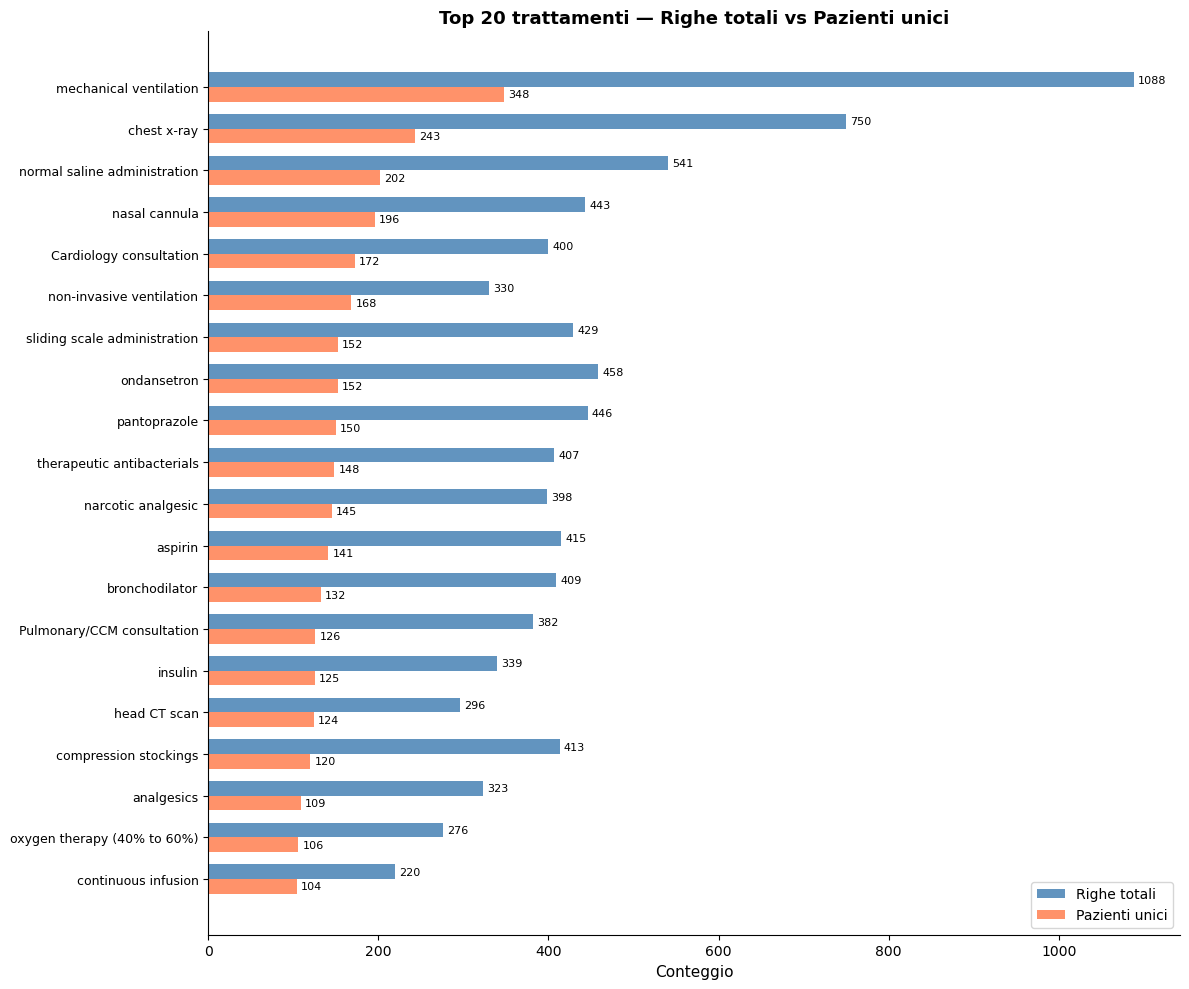

In [3]:
df_counts = pd.DataFrame({
    'righe_totali': df_t['treatmentstring'].value_counts(),
    'pazienti_unici': df_t.groupby('treatmentstring')['patientunitstayid'].nunique()
}).sort_values('pazienti_unici', ascending=True).tail(20)  # top 20

# Accorcia le label (prendi solo l'ultimo livello della gerarchia)
df_counts.index = df_counts.index.str.split('|').str[-1]

fig, ax = plt.subplots(figsize=(12, 10))

y = range(len(df_counts))
height = 0.35

bars1 = ax.barh(
    [i + height/2 for i in y],   #posizione delle barre
    df_counts['righe_totali'],
    height=height,
    label='Righe totali',
    color='steelblue',
    alpha=0.85
)
bars2 = ax.barh(
    [i - height/2 for i in y],
    df_counts['pazienti_unici'],
    height=height,
    label='Pazienti unici',
    color='coral',
    alpha=0.85
)

# Etichette valori
for bar in bars1:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,   #posizione testo centrato e a destra del wigdht
            f'{int(bar.get_width())}', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=8)

ax.set_yticks(list(y))
ax.set_yticklabels(df_counts.index, fontsize=9)
ax.set_xlabel('Conteggio', fontsize=11)
ax.set_title('Top 20 trattamenti — Righe totali vs Pazienti unici', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [4]:
# Calcola metriche per ospedale
hospital_stats = df_p.groupby('hospitalid').agg(
    stay_totali=('patientunitstayid', 'count'),
    pazienti_unici=('uniquepid', 'nunique'),
    tasso_mortalita=('hospitaldischargestatus', lambda x: (x == 'Expired').mean())
).round(3).reset_index()

# Unisci con le info ospedaliere
hospital_stats = hospital_stats.merge(
    df_h[['hospitalid', 'numbedscategory', 'teachingstatus', 'region']],
    on='hospitalid',
    how='left'
)

# Ordina per stay totali
hospital_stats = hospital_stats.sort_values('stay_totali', ascending=False)

print(f"Ospedali totali: {len(hospital_stats)}")
print(f"Tasso mortalità medio: {hospital_stats['tasso_mortalita'].mean():.3f}")
print()
print(hospital_stats.to_string(index=False))


Ospedali totali: 186
Tasso mortalità medio: 0.088

 hospitalid  stay_totali  pazienti_unici  tasso_mortalita numbedscategory teachingstatus    region
        146           40              10            0.050       250 - 499              f      West
        123           30              10            0.067       100 - 249              f     South
        171           25              10            0.120       100 - 249              f      West
        157           25              10            0.280       250 - 499              f      West
        167           24              10            0.000          >= 500              t      West
        155           24              10            0.083       100 - 249              f      West
        154           23              10            0.043       250 - 499              f      West
        310           22              10            0.091       100 - 249              f   Midwest
        243           22              10            0.045 

In [5]:
#analisi dei pazienti
pd.DataFrame({
    
})

2520
1841
1.3688212927756653


Età media: 63.3 anni
Età mediana: 66.0 anni
Missing età: 4


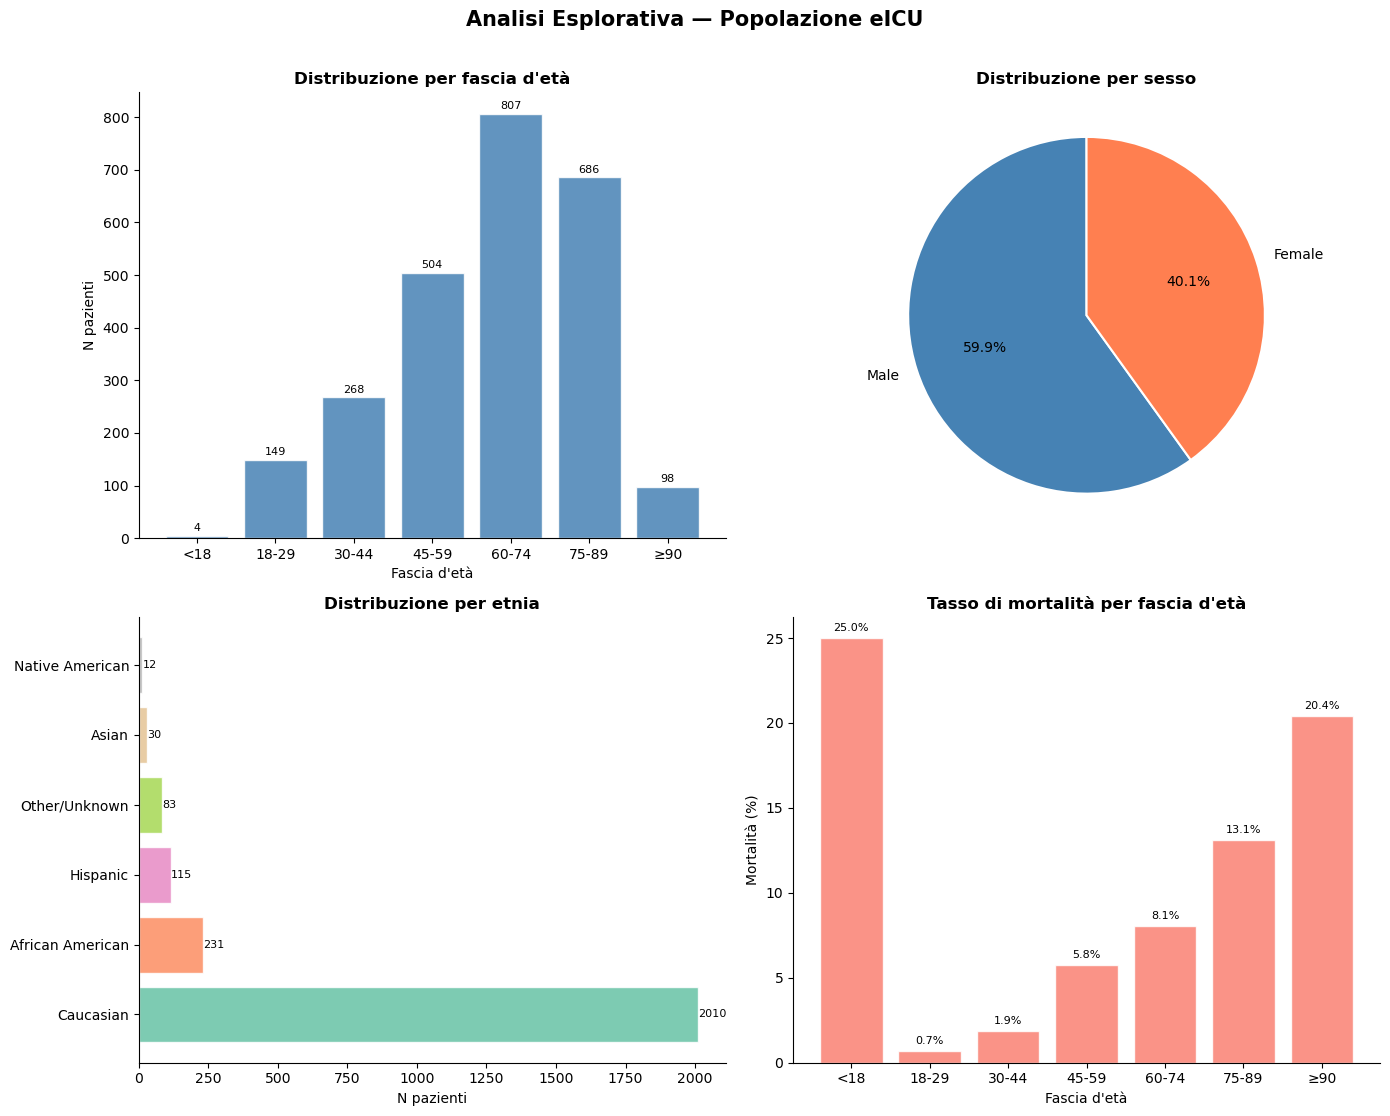


--- MORTALITÀ TOTALE ---
hospitaldischargestatus
Alive      2280
Expired     212
Name: count, dtype: int64

Tasso mortalità ospedaliera: 8.41%

--- SESSO ---
gender
Male      1508
Female    1008
Name: count, dtype: int64

--- ETNIA ---
ethnicity
Caucasian           2010
African American     231
Hispanic             115
Other/Unknown         83
Asian                 30
Native American       12
Name: count, dtype: int64


In [2]:

df_p = pd.read_csv('../data/raw/patient.csv')

# ============================================================
# PULIZIA PRELIMINARE
# ============================================================

# età: eICU usa ">89" come stringa per proteggere la privacy
df_p['age_clean'] = pd.to_numeric(df_p['age'], errors='coerce')
df_p.loc[df_p['age'] == '> 89', 'age_clean'] = 90  # convenzione comune

print(f"Età media: {df_p['age_clean'].mean():.1f} anni")
print(f"Età mediana: {df_p['age_clean'].median():.1f} anni")
print(f"Missing età: {df_p['age_clean'].isna().sum()}")

# ============================================================
# FIGURA — 4 grafici in una
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Analisi Esplorativa — Popolazione eICU', 
             fontsize=15, fontweight='bold', y=1.01)

# --- GRAFICO 1 — Distribuzione età ---
ax1 = axes[0, 0]
bins = [0, 18, 30, 45, 60, 75, 90, 120]
labels = ['<18', '18-29', '30-44', '45-59', '60-74', '75-89', '≥90']
df_p['fascia_eta'] = pd.cut(df_p['age_clean'], bins=bins, labels=labels, right=False)
counts = df_p['fascia_eta'].value_counts().sort_index()
bars = ax1.bar(counts.index, counts.values, color='steelblue', alpha=0.85, edgecolor='white')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
ax1.set_title('Distribuzione per fascia d\'età', fontweight='bold')
ax1.set_xlabel('Fascia d\'età')
ax1.set_ylabel('N pazienti')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- GRAFICO 2 — Torta sesso ---
ax2 = axes[0, 1]
sesso = df_p['gender'].value_counts()
colori = ['steelblue', 'coral', 'lightgray']
wedges, texts, autotexts = ax2.pie(
    sesso.values,
    labels=sesso.index,
    autopct='%1.1f%%',
    colors=colori[:len(sesso)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in autotexts:
    text.set_fontsize(10)
ax2.set_title('Distribuzione per sesso', fontweight='bold')

# --- GRAFICO 3 — Etnia ---
ax3 = axes[1, 0]
etnia = df_p['ethnicity'].value_counts()
colors_etnia = plt.cm.Set2(np.linspace(0, 1, len(etnia)))
bars3 = ax3.barh(etnia.index, etnia.values, color=colors_etnia, alpha=0.85, edgecolor='white')
for bar in bars3:
    ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())), va='center', fontsize=8)
ax3.set_title('Distribuzione per etnia', fontweight='bold')
ax3.set_xlabel('N pazienti')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- GRAFICO 4 — Mortalità per fascia età ---
ax4 = axes[1, 1]
df_p['deceduto'] = (df_p['hospitaldischargestatus'] == 'Expired').astype(int)
mortalita_eta = df_p.groupby('fascia_eta', observed=True)['deceduto'].mean() * 100
bars4 = ax4.bar(mortalita_eta.index, mortalita_eta.values, color='salmon', alpha=0.85, edgecolor='white')
for bar in bars4:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
ax4.set_title('Tasso di mortalità per fascia d\'età', fontweight='bold')
ax4.set_xlabel('Fascia d\'età')
ax4.set_ylabel('Mortalità (%)')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('esplorazione_popolazione.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STATISTICHE TESTUALI
# ============================================================
print("\n--- MORTALITÀ TOTALE ---")
print(df_p['hospitaldischargestatus'].value_counts())
print(f"\nTasso mortalità ospedaliera: {df_p['deceduto'].mean()*100:.2f}%")

print("\n--- SESSO ---")
print(df_p['gender'].value_counts())

print("\n--- ETNIA ---")
print(df_p['ethnicity'].value_counts())